<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 11</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 11</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- Aufgabe 11_01: Markov Prozesse
- Aufgabe 11_02: Integration mit MCMC
- **Aufgabe 11_03: Radom Walks**

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline"> Bonus: Random Walks</td>


Ziel dieser Aufgabe ist es, eine kleine Random Walk Animation zu erstellen.
Wir wollen uns dabei verschiedene Verteilungen anschauen, aus denen wir die Schrittgröße unseres Läufers ziehen.
Eine besonders interessante Verteilung ist die Levy Verteilung, welche aus der Natur inspiriert ist, da Sie z.B. das Verhalten von Tierherden beschreibt, die eine kleine vielversprechende Region sehr gründlich nach Nahrung durchsucht, bevor die Herde dann eine größere Strecke wandert, bis sie wieder eine recourcenreiche Region findet.

#### Hinweis : Nutzen Sie für die Erzeugung von Zufallszahlen verschiedene Verteilungen des Distributions Pakets!


Die Funktion `animate_walker` erzeugt eine Animation, in der die Matrix visualisiert wird, in welcher die bisherigen Positionen des Läufers abgespeichert sind.
Für diese Animation haben wir zwei wichtige Variablen: `Mat` und `pos`

- `Mat` ist eine Matrix die mit Nullen befüllt ist, außer an den Koordinaten wo der Läufer bereits war. Dort sollen Einsen sein.

- `pos` speichert die aktuelle Koordinate des Läufers.

### a) 

Vervollständigen Sie die Funktion `init(N)`. Diese soll ein Lauffeld der Größe NxN und eine Startposition initialisieren. Die Startposition kann z.B. mittig gewählt werden.

In [1]:
function init(N)
    # Startposition mittig im NxN-Feld wählen
    pos = [div(N, 2) + 1, div(N, 2) + 1]

    # Lauffeld mit Nullen initialisieren...
    Mat = zeros(Int, N, N)

    # ...und die Startposition als besuchtes Feld (1) markieren
    Mat[pos[1], pos[2]] = 1

    return pos, Mat
end

init (generic function with 1 method)

### b) 

Vervollständigen Sie nun die Funktion `walker_step!(pos, Mat, dist)`, die ein Update der Position und des Lauffeldes darstellt. In jedem Update bewegt sich der Läufer in eine zufällige Richtung (gleichverteilt) wobei die Schrittweite einer gegebenen Verteilung `dist` folgt. Es gelten hierbei periodische Randbedingungen. 



Vervollständigen Sie die Funktion `walker_step!(pos, Mat, dist)`

- Vervollständigen Sie die Funktion `walker_step!(pos, Mat, dist)` welche die aktuelle Position und die Matrix der besuchten Felder aktualisiert. `dist` ist die Verteilung, aus der die Größe des Schrittes gezogen wird, den der Läufer macht (siehe Aufgabenteil c) ).
- Der Läufer bewegt sich zufällig nach oben, unten, links oder rechts, unabhängig von der Verteilung
- Implementieren Sie periodische Randbedingungen
- Beschreiben sie die implentierte Funktion mit Pseudocode

In [2]:
using Distributions


function walker_step!(pos, Mat, dist)
    N = size(Mat, 1)   # Annahme: quadratisches Feld NxN

    # Zufällige Richtung: oben, unten, links oder rechts (gleichverteilt, je 1/4)
    directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]
    dx, dy = rand(directions)

    # Schrittweite aus der übergebenen Verteilung ziehen.
    # Da wir uns auf einem diskreten Gitter bewegen, wird auf eine
    # ganze, mindestens 1 große Schrittzahl gerundet.
    step = dist()
    step_size = max(1, round(Int, step))

    # Neue Position berechnen, mit periodischen Randbedingungen (mod1
    # bildet 1..N periodisch auf sich selbst ab -> "wrap around")
    new_x = mod1(pos[1] + dx * step_size, N)
    new_y = mod1(pos[2] + dy * step_size, N)

    # Position aktualisieren (pos wird in-place verändert, daher das !)
    pos[1] = new_x
    pos[2] = new_y

    # Besuchtes Feld im Lauffeld markieren
    Mat[new_x, new_y] = 1

    return pos, Mat
end

walker_step! (generic function with 1 method)

**Pseudocode zu `walker_step!(pos, Mat, dist)`:**

```
Funktion walker_step!(pos, Mat, dist):
    N <- Kantenlänge von Mat

    # zufällige Richtung gleichverteilt wählen
    richtung <- zufällig aus {oben, unten, links, rechts}   # je Wahrscheinlichkeit 1/4

    # Schrittweite aus der Verteilung dist ziehen
    schritt <- dist()
    schritt <- max(1, runde(schritt))     # auf ganze Gitterschritte runden, mind. 1

    # neue Position berechnen (mit periodischen Randbedingungen: "wrap around")
    neue_x <- ((pos.x + richtung.dx * schritt - 1) mod N) + 1
    neue_y <- ((pos.y + richtung.dy * schritt - 1) mod N) + 1

    # Position und besuchtes Feld aktualisieren
    pos <- (neue_x, neue_y)
    Mat[neue_x, neue_y] <- 1

    Rückgabe pos, Mat
```

### c) 

Erzeugen Sie verschiedene Funktionen, welche die Schrittgröße für einen Schritt basierend auf verschiedenen Verteilungen zurück geben.

Beispiele sind: 
- Konstante Schrittgrößen
- Uniform veteilte Schrittgrößen in einem Intervall
- Schrittgrößen aus der Levy Verteilung
- Andere Verteilungen (siehe Distributions Dokumentation) mit strikt positiven Werten

#### Hinweis: Sie können Zahlen aus der Levy Verteilung mittels rand(Levy(mu,c)) ziehen, sobald sie das Distributions Paket geladen haben

Beschreiben Sie anschließend das Verhalten des Läufers für die verschiedenen Verteilungen, mit Hilfe der Animation.

In [3]:
using Plots

function animate_walker(dist = () -> rand(1:5); N=20)
    pos, Mat = init(N)
    
    anim = @animate for t in 1:200
        walker_step!(pos, Mat, dist)
        heatmap(Mat, c = :grays)
    end
    
    return gif(anim, "walker.gif", fps = 30)    
end

animate_walker (generic function with 2 methods)

┌ Info: Saved animation to c:\Users\brede\OneDrive\Dokumente\Computerphysik\Übung 11\walker.gif
└ @ Plots C:\Users\brede\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\brede\\OneDrive\\Dokumente\\Computerphysik\\Übung 11\\walker.gif")
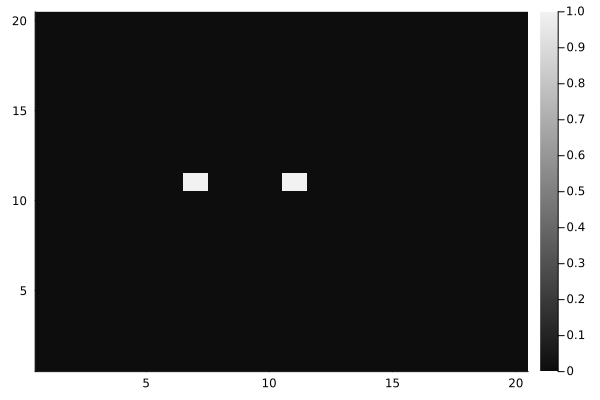

In [9]:
animate_walker()

In [ ]:
# Verschiedene Verteilungen für die Schrittgröße.
# Jede Funktion hat keine Argumente (Signatur () -> Zahl), wie es
# animate_walker / walker_step! erwartet (dist() wird aufgerufen).

# 1) Konstante Schrittgröße
const_step(c=1) = () -> c

# 2) Uniform verteilte Schrittgröße in einem Intervall [a,b]
uniform_step(a=1, b=5) = () -> rand(Uniform(a, b))

# 3) Schrittgröße aus der Levy-Verteilung (schwere Flanke -> gelegentlich sehr große Sprünge)
levy_step(mu=0, c=1) = () -> rand(Levy(mu, c))

# 4) Andere Verteilung mit strikt positiven Werten, z.B. Exponentialverteilung
exponential_step(lambda=1) = () -> rand(Exponential(lambda))

exponential_step (generic function with 2 methods)

┌ Info: Saved animation to c:\Users\brede\OneDrive\Dokumente\Computerphysik\Übung 11\walker.gif
└ @ Plots C:\Users\brede\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\brede\\OneDrive\\Dokumente\\Computerphysik\\Übung 11\\walker.gif")
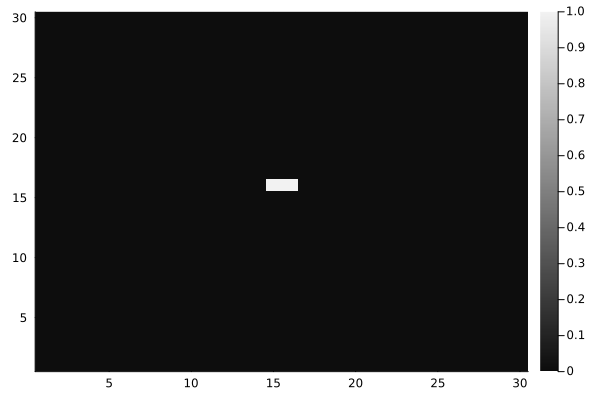

In [5]:
# Animation mit konstanter Schrittgröße (klassischer Random Walk auf dem Gitter)
animate_walker(const_step(1), N=30)

┌ Info: Saved animation to c:\Users\brede\OneDrive\Dokumente\Computerphysik\Übung 11\walker.gif
└ @ Plots C:\Users\brede\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\brede\\OneDrive\\Dokumente\\Computerphysik\\Übung 11\\walker.gif")
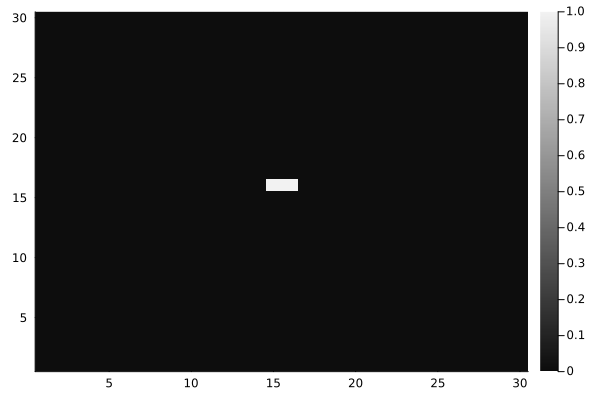

In [6]:
# Animation mit Levy-verteilter Schrittgröße (Levy-Flug)
animate_walker(levy_step(0, 1), N=30)

# Zum Vergleich könnte man z.B. auch aufrufen:
# animate_walker(uniform_step(1, 5), N=30)
# animate_walker(exponential_step(2), N=30)

**Beobachtungen zum Verhalten des Läufers:**

- **Konstante Schrittgröße:** Der Läufer bewegt sich wie ein klassischer diskreter Random Walk mit fester Schrittweite. Das besuchte Gebiet wächst gleichmäßig und diffusiv (typische Diffusionslänge $\propto \sqrt{t}$), es entsteht ein relativ kompakter, langsam wachsender "Fleck" besuchter Felder.

- **Uniform verteilte Schrittgröße:** Ähnlich wie bei konstanter Schrittweite, aber durch die variable (aber weiterhin beschränkte) Schrittlänge wird das besuchte Gebiet etwas schneller und etwas unregelmäßiger erkundet — insgesamt aber immer noch diffusives Verhalten.

- **Levy-verteilte Schrittgröße:** Hier zeigt sich ein deutlich anderes Muster: Die Levy-Verteilung hat einen sogenannten *heavy tail*, d.h. meist macht der Läufer sehr kleine Schritte (dichte, lokale Erkundung eines kleinen Bereichs), aber gelegentlich einen extrem großen Sprung an eine völlig neue Stelle des Gitters. Das erzeugt genau das eingangs beschriebene Verhalten von Tierherden: gründliches, lokales Absuchen einer kleinen Region, gefolgt von einem großen "Sprung" zu einer neuen Region. Man spricht hierbei von einem **Levy-Flug**, der überdiffusives (superdiffusives) Verhalten zeigt — das Gebiet wird insgesamt schneller und mit mehreren getrennten "Clustern" besuchter Felder erkundet, statt eines einzigen zusammenhängenden, langsam wachsenden Flecks.